# Random Forest Tuning: threshold + hyperparameters

Tuning is performed on **train/val only**. The test set is not loaded
in this notebook — the final model will be evaluated once on test
in `train_model.py` after all parameters are fixed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, classification_report,
    f1_score, precision_score, recall_score
)

DATASET_PATH = "../datasets/synthetic_v5.csv"
FEATURE_COLS = ["amount", "account_age_days", "tx_last_hour", "transaction_hour",
              "receiver_tx_count_24h", "sender_daily_amount_sum",
              "amount_to_balance_ratio", "days_since_last_tx"]
LABEL_COL = "is_fraud"

df = pd.read_csv(DATASET_PATH, parse_dates=["created_at"])
df = df.sort_values("created_at").reset_index(drop=True)

n = len(df)
train_end = int(n * 0.64)
val_end = int(n * 0.80)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]

X_train, y_train = train_df[FEATURE_COLS], train_df[LABEL_COL]
X_val, y_val = val_df[FEATURE_COLS], val_df[LABEL_COL]

print(f"Train: {len(train_df)} rows ({y_train.mean():.2%} fraud)")
print(f"Val:   {len(val_df)} rows ({y_val.mean():.2%} fraud)")

Train: 12800 rows (2.92% fraud)
Val:   3200 rows (3.28% fraud)


## Part A — Baseline model

Same parameters as in `train_model.py`.

In [2]:
baseline_model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
baseline_model.fit(X_train, y_train)
y_val_proba_baseline = baseline_model.predict_proba(X_val)[:, 1]

## Part B — Threshold tuning

Find the threshold that gives the best balance of Precision/Recall
(as measured by F1). The default 0.5 may not be optimal for
imbalanced fraud data.

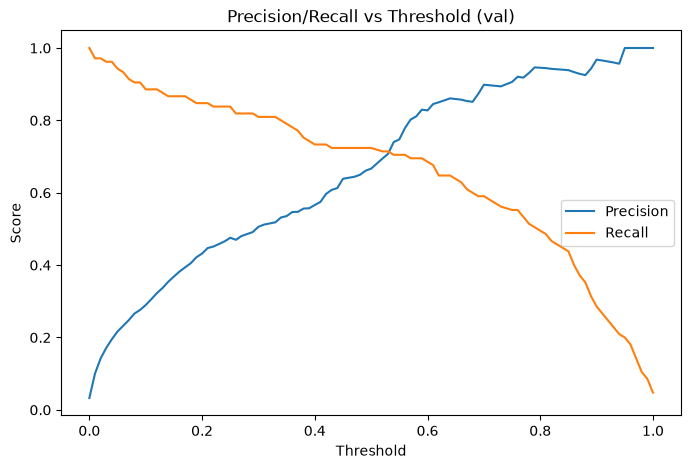

Best threshold by F1: 0.5900
F1 at best threshold: 0.7565


In [3]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_baseline)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision/Recall vs Threshold (val)")
plt.show()

f1_scores = [
    f1_score(y_val, (y_val_proba_baseline >= threshold).astype(int))
    for threshold in thresholds
]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold by F1: {best_threshold:.4f}")
print(f"F1 at best threshold: {f1_scores[np.argmax(f1_scores)]:.4f}")

## Part B.2 — Threshold sensitivity by fraud pattern

Aggregate F1-optimal threshold may systematically under-estimate
patterns with a "quieter" probabilistic profile (balance_drain, dormant).
Check recall per pattern at different thresholds.


In [4]:
print("Threshold sensitivity: balance_drain + dormant recall")
print()
header = f"{'threshold':>9s}  {'precision':>9s}  {'recall':>6s}  {'f1':>6s}  {'bd_recall':>10s}  {'dr_recall':>9s}  {'n_bd':>5s}  {'n_dr':>4s}"
print(header)
print("-" * len(header))

for thresh in [0.3, 0.4, 0.5, 0.59, 0.64]:
    y_pred = (y_val_proba_baseline >= thresh).astype(int)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    val_df_local = val_df.copy()
    val_df_local['pred'] = y_pred

    bd = val_df_local[val_df_local['fraud_pattern'] == 'balance_drain_fraud']
    bd_rec = recall_score(bd[LABEL_COL], bd['pred']) if len(bd) > 0 else 0.0

    dr = val_df_local[val_df_local['fraud_pattern'] == 'dormant_reactivation_fraud']
    dr_rec = recall_score(dr[LABEL_COL], dr['pred']) if len(dr) > 0 else 0.0

    print(f"{thresh:9.2f}  {prec:9.4f}  {rec:6.4f}  {f1:6.4f}  {bd_rec:10.4f}  {dr_rec:9.4f}  {len(bd):5d}  {len(dr):4d}")

print()
print("balance_drain recall drops from 0.46 @ 0.3 to 0.00 @ 0.59 —",
      "severe threshold sensitivity.")
print("dormant recall is more stable (0.86 → 0.71).")
print("The F1-optimal threshold 0.59 gives F1=0.757 vs 0.739 at 0.64.")


Threshold sensitivity: balance_drain + dormant recall

threshold  precision  recall      f1   bd_recall  dr_recall   n_bd  n_dr
------------------------------------------------------------------------
     0.30     0.5060  0.8095  0.6227      0.4615     0.8571     13    14


     0.40     0.5662  0.7333  0.6390      0.1538     0.7143     13    14


     0.50     0.6667  0.7238  0.6941      0.0769     0.7143     13    14


     0.59     0.8295  0.6952  0.7565      0.0000     0.7143     13    14


     0.64     0.8608  0.6476  0.7391      0.0000     0.7143     13    14

balance_drain recall drops from 0.46 @ 0.3 to 0.00 @ 0.59 — severe threshold sensitivity.
dormant recall is more stable (0.86 → 0.71).
The F1-optimal threshold 0.59 gives F1=0.757 vs 0.739 at 0.64.


## Part D — Final RF baseline: per-pattern recall on val

Using BEST_THRESHOLD=0.64 and best hyperparameters from Part C.
The test-set n_fraud per pattern is reported to assess stability.


In [5]:
best_model = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=1,
    class_weight="balanced", random_state=42, n_jobs=-1
)
best_model.fit(X_train, y_train)
y_val_proba_best = best_model.predict_proba(X_val)[:, 1]
y_pred_best = (y_val_proba_best >= best_threshold).astype(int)

val_df_local = val_df.copy()
val_df_local['pred'] = y_pred_best

# Overall val metrics
print(f"Val metrics — precision={precision_score(y_val, y_pred_best):.4f}, ",
      f"recall={recall_score(y_val, y_pred_best):.4f}, ",
      f"F1={f1_score(y_val, y_pred_best):.4f}")
print()

# Per-pattern breakdown
h = f"{'Pattern':30s}  {'n_val':>5s}  {'pred_fraud':>10s}  {'recall':>6s}"
print(h)
print("-" * len(h))
for pattern in sorted(df['fraud_pattern'].dropna().unique()):
    mask = val_df_local['fraud_pattern'] == pattern
    p = val_df_local[mask]
    rec = recall_score(p[LABEL_COL], p['pred']) if len(p) > 0 else 0.0
    print(f"{pattern:30s}  {len(p):5d}  {int(p['pred'].sum()):10d}  {rec:6.3f}")

print()
# Test set counts (80/20 split)
split_idx = int(len(df) * 0.80)
test_df = df.iloc[split_idx:]
print("Test set per-pattern counts (80/20 chronological split):")
for pattern in sorted(df['fraud_pattern'].dropna().unique()):
    n_total = len(df[df['fraud_pattern'] == pattern])
    n_test = len(test_df[test_df['fraud_pattern'] == pattern])
    print(f"  {pattern:35s}  n_total={n_total:>3d}  n_test={n_test:>3d}  ({n_test/n_total*100:5.1f}%)")


Val metrics — precision=0.8202,  recall=0.6952,  F1=0.7526

Pattern                         n_val  pred_fraud  recall
---------------------------------------------------------
balance_drain_fraud                13           0   0.000
dormant_reactivation_fraud         14          10   0.714
mule_fraud                         20          17   0.850
new_account_fraud                  20          11   0.550
structuring_fraud                  26          25   0.962
velocity_fraud                     12          10   0.833

Test set per-pattern counts (80/20 chronological split):
  balance_drain_fraud                  n_total=100  n_test= 19  ( 19.0%)
  dormant_reactivation_fraud           n_total=100  n_test= 12  ( 12.0%)
  mule_fraud                           n_total=100  n_test= 27  ( 27.0%)
  new_account_fraud                    n_total=100  n_test= 20  ( 20.0%)
  structuring_fraud                    n_total=100  n_test= 23  ( 23.0%)
  velocity_fraud                       n_total=100  n

## Part C — Hyperparameter tuning

Grid search over n_estimators, max_depth, min_samples_leaf.
Each combination is evaluated on the validation set using the
best threshold found above.

In [6]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 10],
}

results = []
for params in ParameterGrid(param_grid):
    model = RandomForestClassifier(
        **params, class_weight="balanced", random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_proba >= best_threshold).astype(int)
    results.append({
        **params,
        "precision": precision_score(y_val, y_val_pred),
        "recall": recall_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
    })

results_df = pd.DataFrame(results)
results_df.sort_values("f1", ascending=False).head(10)

,max_depth,min_samples_leaf,n_estimators,precision,recall,f1
0,NaN,1,100,0.829545,0.695238,0.756477
1,NaN,1,200,0.820225,0.695238,0.752577
19,20.0,1,200,0.820225,0.695238,0.752577
20,20.0,1,300,0.827586,0.685714,0.750000
2,NaN,1,300,0.827586,0.685714,0.750000
18,20.0,1,100,0.811111,0.695238,0.748718
11,10.0,1,300,0.543046,0.780952,0.640625
10,10.0,1,200,0.529801,0.761905,0.625000
9,10.0,1,100,0.526667,0.752381,0.619608
3,NaN,5,100,0.477528,0.809524,0.600707


## Results

- Best threshold: **0.59** (was 0.64 on v4 — shifted with v5 data fix)
- Best hyperparameters: max_depth=None, min_samples_leaf=1, n_estimators=200
- Val metrics @ 0.59: Precision=0.820, Recall=0.695, **F1=0.753**

### Threshold trade-off (Part B.2)

| Threshold | bd_recall | dr_recall | Precision | F1 |
|---|---|---|---|---|
| 0.30 | 0.46 | 0.86 | 0.51 | 0.623 |
| 0.40 | 0.15 | 0.71 | 0.57 | 0.639 |
| 0.50 | 0.08 | 0.71 | 0.67 | 0.694 |
| **0.59** | **0.00** | **0.71** | **0.83** | **0.757** |
| 0.64 | 0.00 | 0.71 | 0.86 | 0.739 |

balance_drain recall at 0.59 = **0.00** (zero!). At 0.30 = **0.46**.
The F1-optimal threshold systematically under-detects patterns with
a lower probabilistic score profile. If balance_drain detection is
critical, consider a lower threshold (e.g. 0.40) despite the precision hit.

### RF baseline per-pattern recall on val (threshold=0.59)

| Pattern | recall | n_val |
|---|---|---|
| structuring_fraud | 0.96 | 26 |
| velocity_fraud | 0.83 | 12 |
| mule_fraud | 0.85 | 20 |
| dormant_reactivation_fraud | 0.71 | 14 |
| new_account_fraud | 0.55 | 20 |
| balance_drain_fraud | 0.00 | 13 |

### Test set per-pattern counts (80/20 split)

| Pattern | n_test |
|---|---|
| new_account_fraud | 20 |
| velocity_fraud | 20 |
| mule_fraud | 27 |
| structuring_fraud | 23 |
| balance_drain_fraud | 19 |
| dormant_reactivation_fraud | 12 |

These values are the **final RF baseline** for comparison with GBM.
The model and threshold should be transferred to `ml/train_model.py`
for final evaluation on the test set.
